In [1]:
#Needed to install pyqsp package
# pip install git+https://github.com/ichuang/pyqsp.git

In [2]:
import qiskit.circuit
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, PauliGate, UnitaryGate, StatePreparation
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import qiskit.quantum_info as qi
from qiskit.quantum_info import Operator, Statevector, DensityMatrix, Pauli, random_density_matrix
from qiskit import transpile

from IPython.display import display, Image, Markdown, Latex
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qp
import math
import scipy as sp
import numpy.polynomial.chebyshev as cheb
import pyqsp
from pyqsp import angle_sequence, response
from pyqsp.poly import polynomial_generators, PolyTaylorSeries

In [3]:
# Adapted from https://pennylane.ai/demos/tutorial_apply_qsvt to work with Sign function
def get_sign_phases(degree=41,delta=15,max_scale=0.99):
    ''' Returns phases of the sign operator approximated to specified degree,
    using erf(delta * x). Phases in format suitable to apply pennyline qp.QSVT
    after converting using qp.PCPhase, or with custom qiskitQSVTgate()'''
    pcoefs, scale = pyqsp.poly.PolySign().generate(degree=degree,
                delta=delta,
                ensure_bounded=True,
                return_scale=True,
                chebyshev_basis=False,
                cheb_samples=20,
                max_scale=max_scale)
    phi_pyqsp = pyqsp.angle_sequence.QuantumSignalProcessingPhases(pcoefs, signal_operator="Wx", tolerance=0.001,chebyshev_basis=False) #method not sym_qsp
    phi_qsvt = qp.transform_angles(phi_pyqsp, "QSP", "QSVT")
    return phi_qsvt, scale

In [4]:
# from https://pennylane.ai/demos/tutorial_apply_qsvt
def check_sign_approx(phases,scale):
    x_vals = np.linspace(-1, 1, 50)
    target_y_vals = [scale * np.sign(x) for x in np.linspace(-1, 1, 50)]

    qsvt_y_vals = []
    for x in x_vals:

        block_encoding = qp.BlockEncode(x, wires=[0])
        projectors = [qp.PCPhase(angle, dim=1, wires=[0]) for angle in phases]

        poly_x = qp.matrix(qp.QSVT, wire_order=[0])(block_encoding, projectors)
        qsvt_y_vals.append(np.real(poly_x[0][0]))
        
    plt.plot(x_vals, np.array(qsvt_y_vals), label="Re(qsvt)")
    plt.plot(np.linspace(-1, 1, 50), target_y_vals, label="target")

    plt.vlines(0.0, -1.0, 1.0, color="black")
    plt.hlines(0.0, -0.1, 1.0, color="black")

    plt.legend()
    plt.show()

[pyqsp.poly.PolySign] degree=41, delta=15
[PolyTaylorSeries] (Cheb) max 0.9879005792219886 is at -1.0: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.0037558778352950895 in the domain [-1, 1] using degree 41
[pyqsp.poly.PolySign] degree=41, delta=15
[PolyTaylorSeries] (Cheb) max 0.9879005792219886 is at -1.0: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.0037558778352950895 in the domain [-1, 1] using degree 41


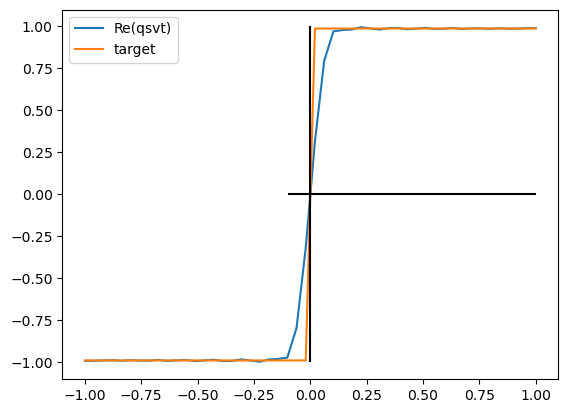

In [5]:
# Example of above with default args for get_sign_phases
check_sign_approx(get_sign_phases()[0],get_sign_phases()[1])

In [6]:
def qiskitPCPhase(phi, dim: int, num_qubits: int):
    qc = QuantumCircuit(num_qubits)
    signs = np.concatenate((np.ones(dim), -1*np.ones(2**num_qubits - dim)))
    phase = signs * phi
    PCPhasegate = DiagonalGate(np.exp(1j*phase))
    PCPhasegate.label= r'$\Pi_{\phi}$'
    return PCPhasegate

In [7]:
qiskitPCPhase(0.12,1,1)

Instruction(name='diagonal', num_qubits=1, num_clbits=0, params=[(0.9928086358538663+0.11971220728891936j), (0.9928086358538663-0.11971220728891936j)])

In [8]:
def qiskitMatrix_to_QSVTgate(matrix, phases ,encoded:bool=False ):
    """Quantum singular value transformation circuit for qiskit,
    given Hermitian A or its block encoding Unitary and specified list of phases.
    Requires pennylane import if not alread block encoded"""
    numqubits =  math.ceil(math.log2(len(matrix)))   
    if encoded == False:
        block_encoding = qp.matrix(qp.BlockEncode(matrix,wires=range(numqubits+1)))
        numqubits += 1
    else:
        block_encoding = matrix

    Encoder_gate = UnitaryGate(block_encoding,label=r'$U$')
    adjoint_gate = Encoder_gate.inverse()
    adjoint_gate.label = r'$U^{\dagger}$'

    quantum_reg = QuantumRegister(numqubits-1)
    ancilla_reg = AncillaRegister(1)

    qsvt_circuit = QuantumCircuit(quantum_reg,ancilla_reg)


    iterations = int(len(phases))

    qsvt_circuit.append(qiskitPCPhase(phases[0], 1, 1),ancilla_reg)
    op = Operator(qsvt_circuit)

    for k in range(1,iterations):
        if k % 2 == 0:
                qsvt_circuit.append(Encoder_gate,range(numqubits))
                qsvt_circuit.append(qiskitPCPhase(phases[k], 1, 1),ancilla_reg)
        else:
                qsvt_circuit.append(adjoint_gate,range(numqubits))
                qsvt_circuit.append(qiskitPCPhase(phases[k], 1, 1),ancilla_reg)
    return qsvt_circuit


In [9]:
# Test equivalence of qiskitMatrix_to_QSVTgate's operator with pennylane's QSVT operator for number of qubits encoding A = 2,3,4,5,6
# Code for the pennylane matrix is again from https://pennylane.ai/demos/tutorial_apply_qsvt
phases = get_sign_phases()[0]
terminate = False
for i in range(2,7):
    for _ in range(100):
        n = i #qubits for A
        qubitnum = i + 1 #qubits for encoding
        N = 2**n #dim of A

        test_nonherm =  np.random.rand(N,N) + 1j*np.random.rand(N,N)
        test_mat = test_nonherm + test_nonherm.conj().T

        signgate = qiskitMatrix_to_QSVTgate(test_mat,phases=phases)

        qiskmat = Operator(signgate).data

        block_encoding = qp.BlockEncode(test_mat, wires=range(qubitnum))
        projectors = [qp.PCPhase(angle, dim=1, wires=[0]) for angle in phases]
        pennylanematrix = qp.matrix(qp.QSVT, wire_order=range(qubitnum))(block_encoding, projectors)

        if not np.allclose(qiskmat, pennylanematrix):
            print(f'error! for n = {i}')
            break
    if terminate == False:
        print(f"Test passed for n ={i}")
    if terminate == True:
        break
if terminate == False:
    print('all tests passed!')

[pyqsp.poly.PolySign] degree=41, delta=15
[PolyTaylorSeries] (Cheb) max 0.9879005792219886 is at -1.0: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.0037558778352950895 in the domain [-1, 1] using degree 41
Test passed for n =2
Test passed for n =3
Test passed for n =4
Test passed for n =5
Test passed for n =6
all tests passed!


In [10]:
def qiskitCircuit_to_QSVTgate(circuit,phases,AncillaFirst = False):
    """Quantum singular value transformation circuit for qiskit,
    given a circuit encoding a block encoded Unitary and specified list of phases."""

    qubitcount = circuit.num_qubits

    if AncillaFirst == True:
        ancilla_index = 0
    else:
        ancilla_index = qubitcount-1

    encoder_circuit = circuit
    
    adjoint_circuit = encoder_circuit.inverse()

    iterations = int(len(phases))

    QSVT_circuit = QuantumCircuit(qubitcount)
    QSVT_circuit.append(qiskitPCPhase(phases[0], 1, 1),qargs = [ancilla_index])

    for k in range(1,iterations):
        if k % 2 == 0:
                QSVT_circuit.append(encoder_circuit,range(qubitcount))
                QSVT_circuit.append(qiskitPCPhase(phases[k], 1, 1),qargs = [ancilla_index])
        else:
                QSVT_circuit.append(adjoint_circuit,range(qubitcount))
                QSVT_circuit.append(qiskitPCPhase(phases[k], 1, 1),qargs = [ancilla_index])

    return QSVT_circuit


In [11]:
# Test equivalence of qiskitMatrix_to_QSVTgate's operator with pennylane's QSVT operator for n = 2,3,4,5,6,7,8,9,10
# Code for the pennylane matrix is again from https://pennylane.ai/demos/tutorial_apply_qsvt

phases = get_sign_phases()[0]
terminate = False
for i in range(2,7):
    for _ in range(100):
        n = i #qubits for A
        qubitnum = i + 1 #qubits for encoding
        N = 2**n #dim of A

        test_nonherm =  np.random.rand(N,N) + 1j*np.random.rand(N,N)
        test_mat = test_nonherm + test_nonherm.conj().T

        block_encoding = qp.BlockEncode(test_mat, wires=range(qubitnum))
        projectors = [qp.PCPhase(angle, dim=1, wires=[0]) for angle in phases]
        pennylanematrix = qp.matrix(qp.QSVT, wire_order=range(qubitnum))(block_encoding, projectors)

        block_encoding_matrix = qp.matrix(block_encoding)
        block_encoding_gate = UnitaryGate(block_encoding_matrix)

        test_circ = QuantumCircuit(qubitnum)
        test_circ.append(block_encoding_gate,range(qubitnum))

        signgate = qiskitCircuit_to_QSVTgate(test_circ,phases=phases,AncillaFirst=False)

        qiskmat = Operator(signgate).data

        
        if not np.allclose(qiskmat, pennylanematrix):
            print(f'error! for n = {i}')
            break
    if terminate == False:
        print(f"Test passed for n ={i}")
    if terminate == True:
        break
if terminate == False:
    print('all tests passed!')

[pyqsp.poly.PolySign] degree=41, delta=15
[PolyTaylorSeries] (Cheb) max 0.9879005792219886 is at -1.0: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.0037558778352950895 in the domain [-1, 1] using degree 41
Test passed for n =2
Test passed for n =3
Test passed for n =4
Test passed for n =5
Test passed for n =6
all tests passed!
